#**1. Descriptive Analytics**

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from numpy import nan as NA
warnings.filterwarnings('ignore')
import sklearn_pandas
from sklearn.model_selection import train_test_split
#from sklearn.metrics import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score,precision_score,recall_score,roc_auc_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier # Added StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from keras.models import Sequential
from keras.layers import Dense,Activation
from keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

--- Numerical Statistics ---
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110

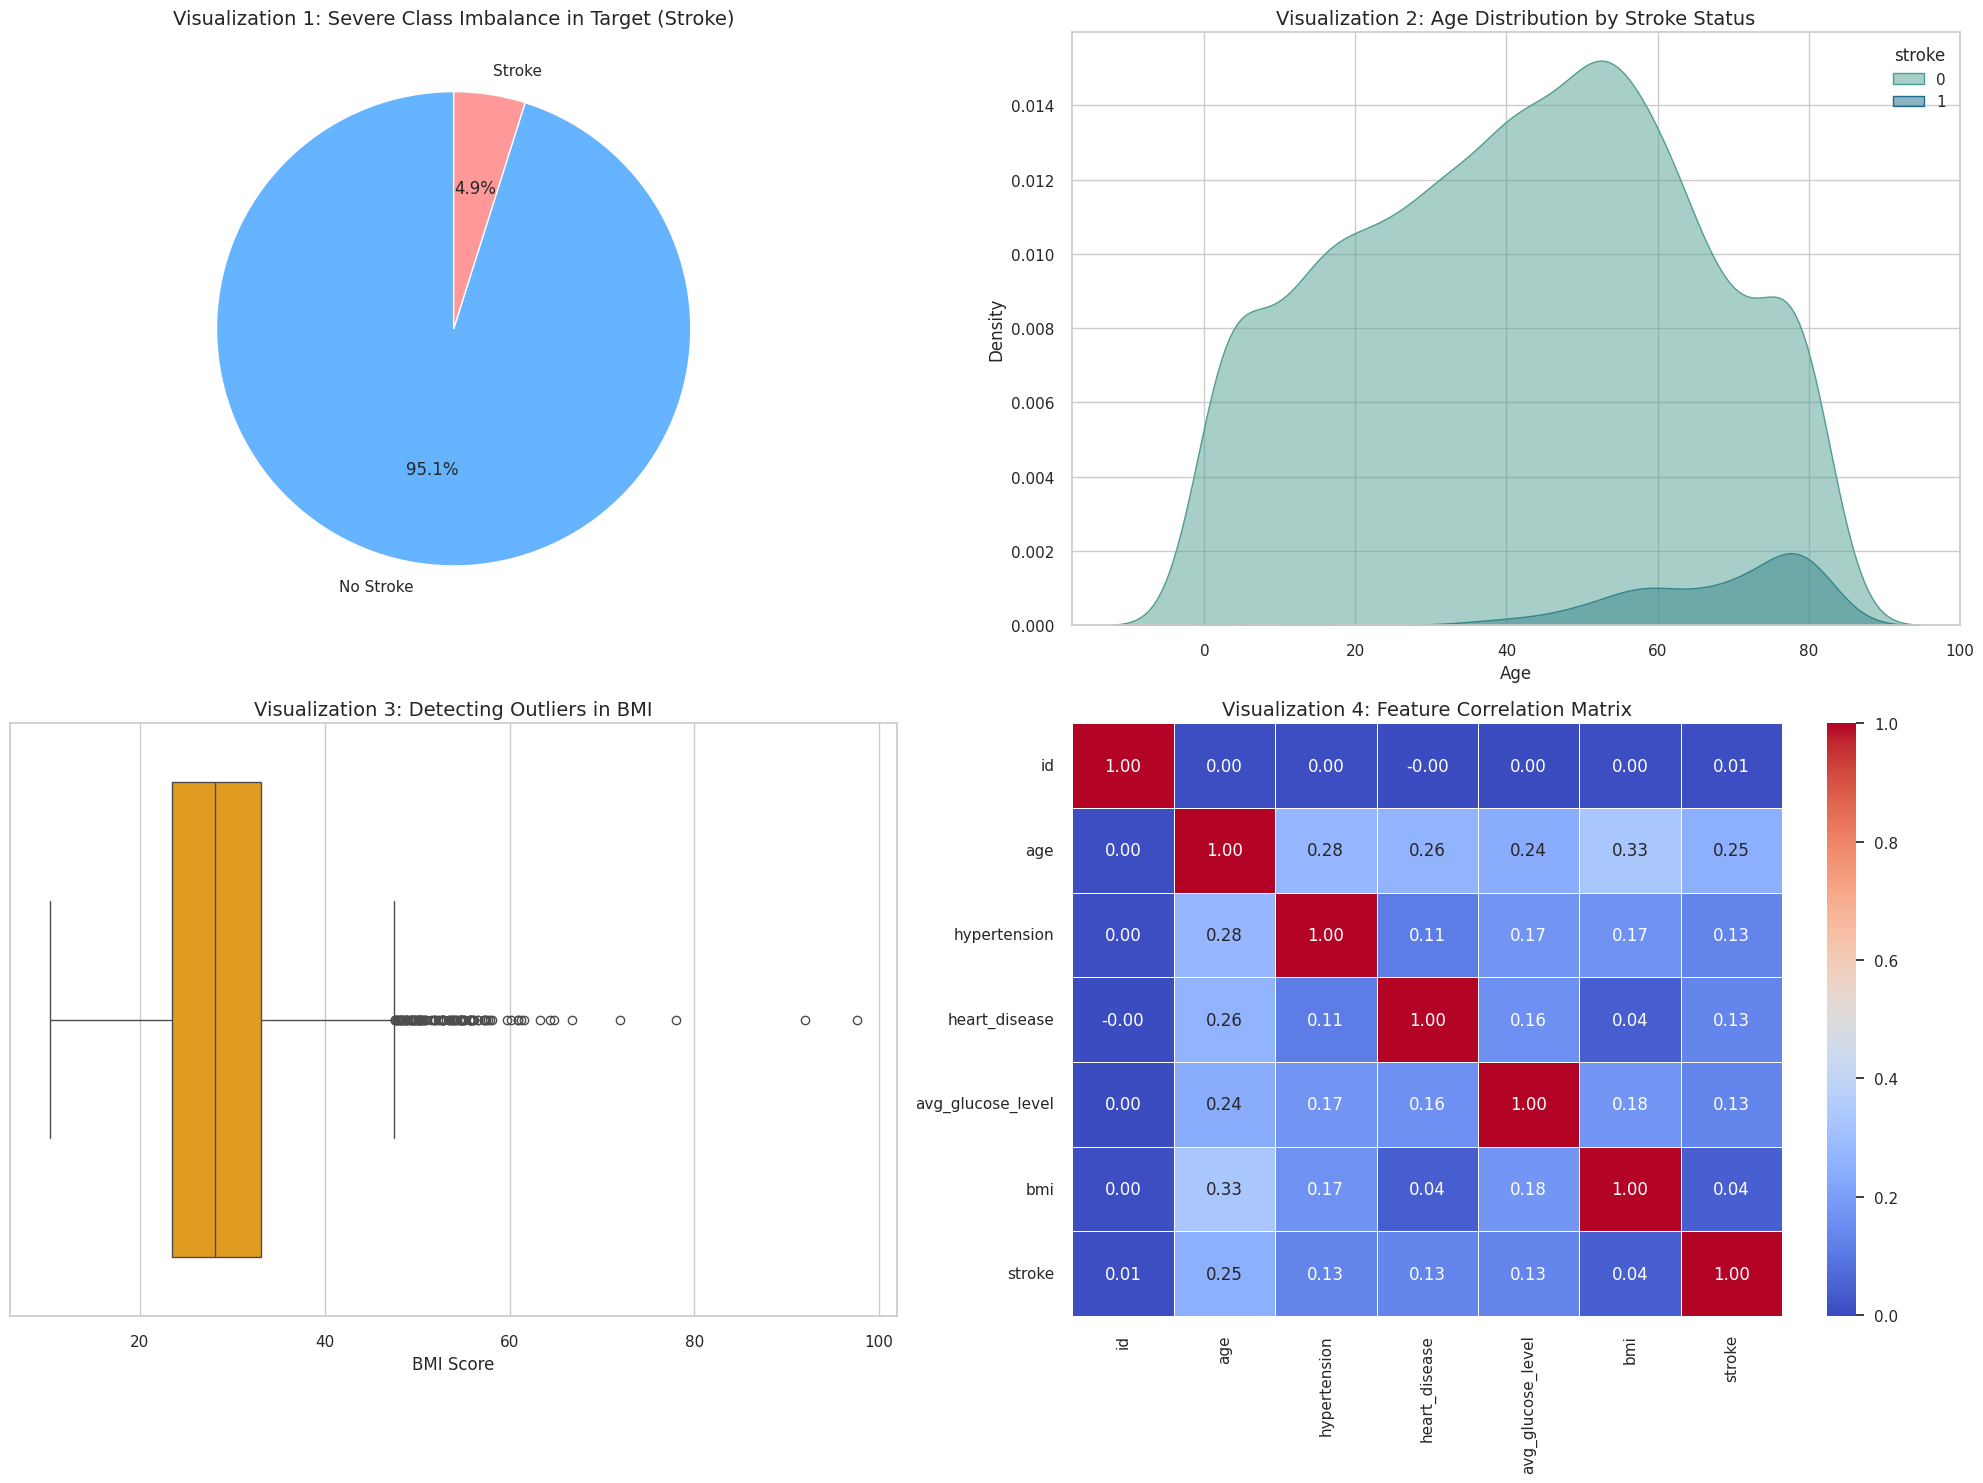

In [163]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the Data
# Ensure the file is uploaded to the 'Files' tab on the left in Colab
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# 2. Display Basic Statistics for All 12 Attributes
print("--- Data Info ---")
print(df.info())
print("\n--- Numerical Statistics ---")
print(df.describe())
print("\n--- Categorical Statistics ---")
print(df.describe(include=['object']))

# Check for missing values explicitly
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Check target balance
print("\n--- Stroke Balance ---")
print(df['stroke'].value_counts(normalize=True))

# 3. Create 4 Visualizations (Rubric Requirement 1.b)

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 15))

# Graph 1: Target Imbalance (Pie Chart)
plt.subplot(2, 2, 1)
stroke_counts = df['stroke'].value_counts()
plt.pie(stroke_counts, labels=['No Stroke', 'Stroke'], autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
plt.title('Visualization 1: Severe Class Imbalance in Target (Stroke)', fontsize=14)

# Graph 2: Distribution of Key Numerical Features (KDE Plot)
plt.subplot(2, 2, 2)
sns.kdeplot(data=df, x='age', hue='stroke', fill=True, palette='crest', alpha=0.5)
plt.title('Visualization 2: Age Distribution by Stroke Status', fontsize=14)
plt.xlabel('Age')

# Graph 3: Outlier Detection (Boxplot for BMI)
plt.subplot(2, 2, 3)
sns.boxplot(x=df['bmi'], color='orange')
plt.title('Visualization 3: Detecting Outliers in BMI', fontsize=14)
plt.xlabel('BMI Score')

# Graph 4: Correlation Heatmap
plt.subplot(2, 2, 4)
# We select only numerical columns for correlation
numerical_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numerical_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Visualization 4: Feature Correlation Matrix', fontsize=14)

plt.tight_layout()
plt.show()

## **Basic Statistics**

In [164]:
sk = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [165]:
sk.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [166]:
sk.shape

(5110, 12)

In [167]:
sk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [168]:
sk.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [169]:
sk.dtypes

,0
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


In [170]:
sk.value_counts()

,,,,,,,,,,,,count
id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,
72940,Female,2.0,0,0,No,children,Urban,102.92,17.6,Unknown,0,1
77,Female,13.0,0,0,No,children,Rural,85.81,18.6,Unknown,0,1
84,Male,55.0,0,0,Yes,Private,Urban,89.17,31.5,never smoked,0,1
91,Female,42.0,0,0,No,Private,Urban,98.53,18.5,never smoked,0,1
99,Female,31.0,0,0,No,Private,Urban,108.89,52.3,Unknown,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
354,Female,65.0,0,0,Yes,Private,Urban,72.49,28.9,smokes,0,1
338,Female,43.0,0,0,Yes,Private,Rural,110.32,28.4,never smoked,0,1
321,Female,79.0,0,0,No,Self-employed,Rural,71.98,36.4,never smoked,0,1


In [171]:
sk['gender'].value_counts()
(sk['gender'].value_counts(normalize=True) * 100).round(2)


,proportion
gender,
Female,58.59
Male,41.39
Other,0.02


In [172]:
gender_counts = sk['gender'].value_counts()
gender_percent = sk['gender'].value_counts(normalize=True) * 100

pd.DataFrame({
    'Count': gender_counts,
    'Percentage (%)': gender_percent.round(2)
})

,Count,Percentage (%)
gender,,
Female,2994,58.59
Male,2115,41.39
Other,1,0.02


In [173]:
ever_married_counts = sk['ever_married'].value_counts()
ever_married_percent = sk['ever_married'].value_counts(normalize=True) * 100

pd.DataFrame({
    'Count': ever_married_counts,
    'Percentage (%)': ever_married_percent.round(2)
})

,Count,Percentage (%)
ever_married,,
Yes,3353,65.62
No,1757,34.38


In [174]:
work_type_counts = sk['work_type'].value_counts()
work_type_percent = sk['work_type'].value_counts(normalize=True) * 100

pd.DataFrame({
    'Count': work_type_counts,
    'Percentage (%)': work_type_percent.round(2)
})

,Count,Percentage (%)
work_type,,
Private,2925,57.24
Self-employed,819,16.03
children,687,13.44
Govt_job,657,12.86
Never_worked,22,0.43


In [175]:
residence_counts = sk['Residence_type'].value_counts()
residence_percent = sk['Residence_type'].value_counts(normalize=True) * 100

pd.DataFrame({
    'Count': residence_counts,
    'Percentage (%)': residence_percent.round(2)
})

,Count,Percentage (%)
Residence_type,,
Urban,2596,50.8
Rural,2514,49.2


In [176]:
smoking_counts = sk['smoking_status'].value_counts()
smoking_percent = sk['smoking_status'].value_counts(normalize=True) * 100

pd.DataFrame({
    'Count': smoking_counts,
    'Percentage (%)': smoking_percent.round(2)
})

,Count,Percentage (%)
smoking_status,,
never smoked,1892,37.03
Unknown,1544,30.22
formerly smoked,885,17.32
smokes,789,15.44


In [177]:
stroke_counts = sk['stroke'].value_counts()
stroke_percent = sk['stroke'].value_counts(normalize=True) * 100

pd.DataFrame({
    'Count': stroke_counts,
    'Percentage (%)': stroke_percent.round(2)
})

,Count,Percentage (%)
stroke,,
0,4861,95.13
1,249,4.87


##**Visualisation**

#### Box Plot

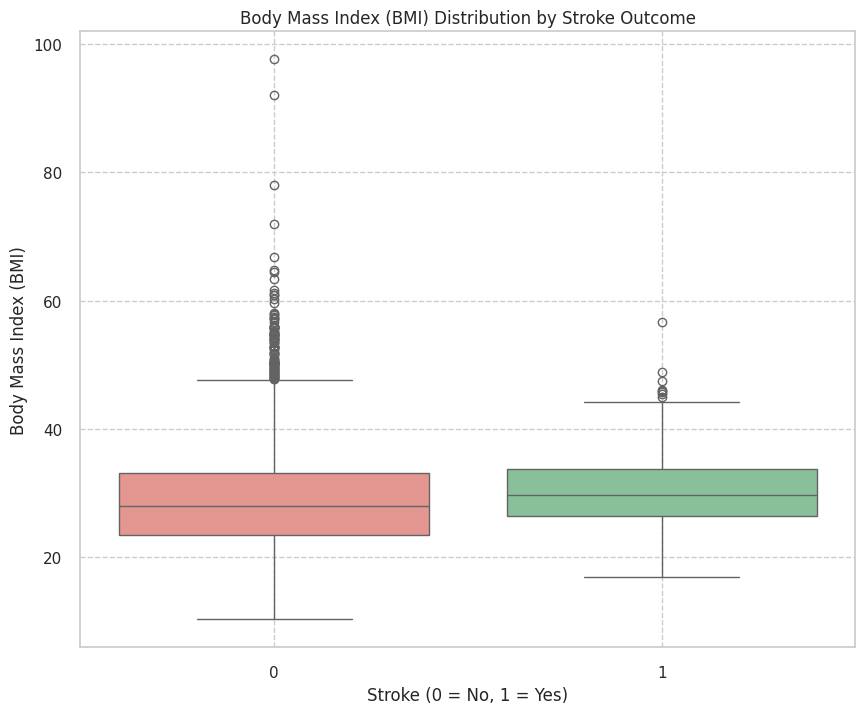

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = ["#f28b82", "#81c995"]

plt.figure(figsize=(10, 8))
sns.boxplot(x='stroke', y='bmi', data=sk, palette=palette)
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Body Mass Index (BMI)')
plt.title('Body Mass Index (BMI) Distribution by Stroke Outcome')
plt.grid(True, linestyle='--', alpha=1)
plt.show()

#### Violin Plot

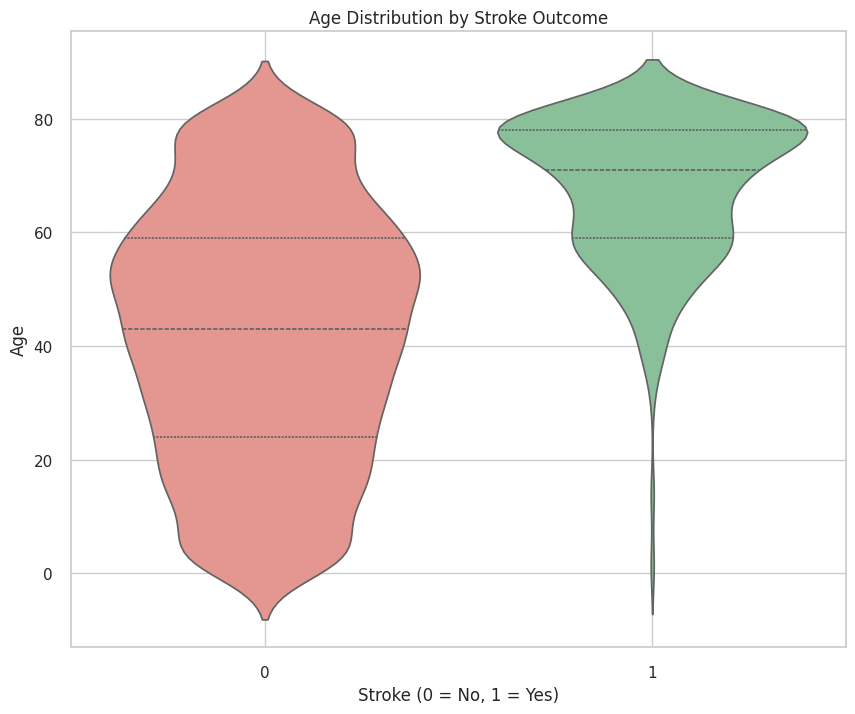

In [179]:

custom_palette = ["#f28b82", "#81c995"]

plt.figure(figsize=(10, 8))
sns.violinplot(
    x='stroke',
    y='age',
    data=sk,
    palette=custom_palette,
    inner='quartile'
)

plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.title('Age Distribution by Stroke Outcome')

plt.grid(alpha=1.0)

plt.show()



####Bar Plot

In [180]:
# calculate stroke proportions by smoking status
smoking_stroke_prop = (
    sk.groupby('smoking_status')['stroke']
    .mean()
    .reset_index()
)

smoking_stroke_prop

,smoking_status,stroke
0,Unknown,0.030440
1,formerly smoked,0.079096
2,never smoked,0.047569
3,smokes,0.053232


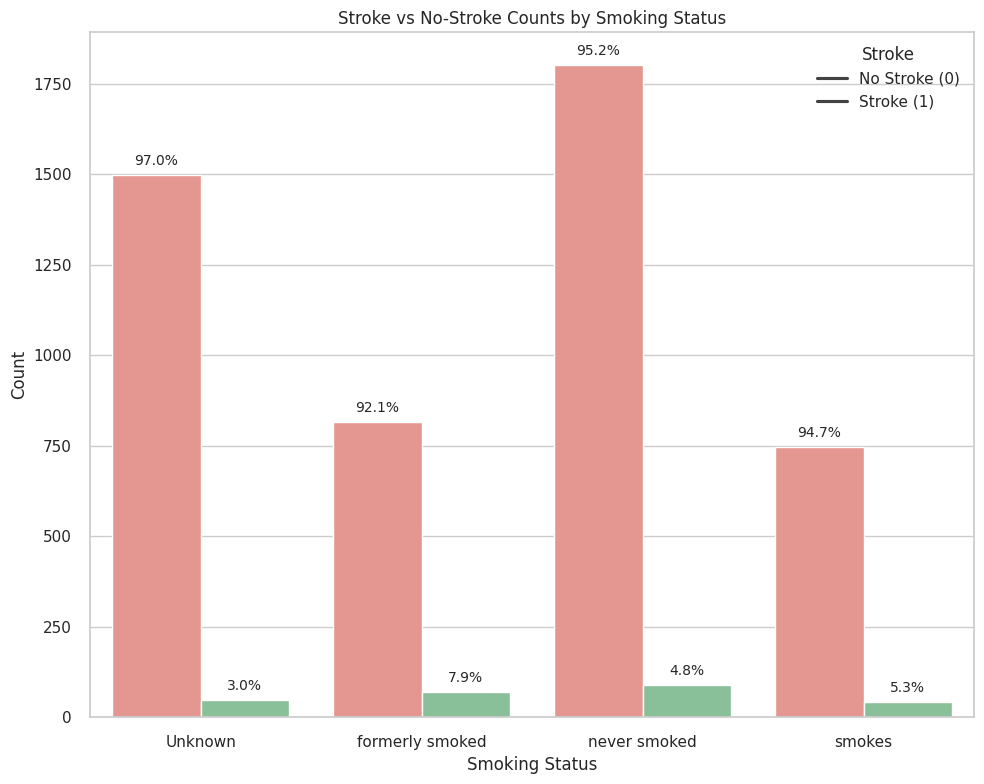

In [181]:
counts_hs = sk.groupby(['smoking_status', 'stroke']).size().reset_index(name='count')

# Calculate total counts per smoking_status to get percentages
total_counts = sk.groupby('smoking_status')['stroke'].count().reset_index(name='total')
counts_hs = counts_hs.merge(total_counts, on='smoking_status')
counts_hs['percentage'] = (counts_hs['count'] / counts_hs['total']) * 100

# Create the plot
plt.figure(figsize=(10, 8))
ax = sns.barplot(x='smoking_status', y='count', hue='stroke', data=counts_hs, palette=palette)

# Add title and labels
plt.title('Stroke vs No-Stroke Counts by Smoking Status', fontsize=12)
plt.xlabel('Smoking Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Stroke', labels=['No Stroke (0)', 'Stroke (1)'])

# Get the order of x-axis categories plotted by seaborn
x_labels = [label.get_text() for label in ax.get_xticklabels()]

# Iterate through the containers (hue groups)
for container_idx, container in enumerate(ax.containers):
    # Determine the stroke value for this container (0 or 1)
    # The hue order is usually sorted, 0 then 1
    stroke_val = counts_hs['stroke'].unique()[container_idx] # Assuming sorted order 0, 1

    for i, bar in enumerate(container):
        # Get the smoking_status category for this bar
        category = x_labels[i]

        # Find the corresponding row in the dataframe
        row = counts_hs[(counts_hs['smoking_status'] == category) & (counts_hs['stroke'] == stroke_val)]

        if not row.empty:
            percentage = row['percentage'].values[0]
            count = row['count'].values[0]

            # Format the label
            label = f"{percentage:.1f}%"

            # Add text annotation
            ax.annotate(label,
                        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                        textcoords='offset points')

plt.tight_layout()
plt.savefig('grouped_bar_chart_stroke_smoking_percent.png')

#### Heat Map

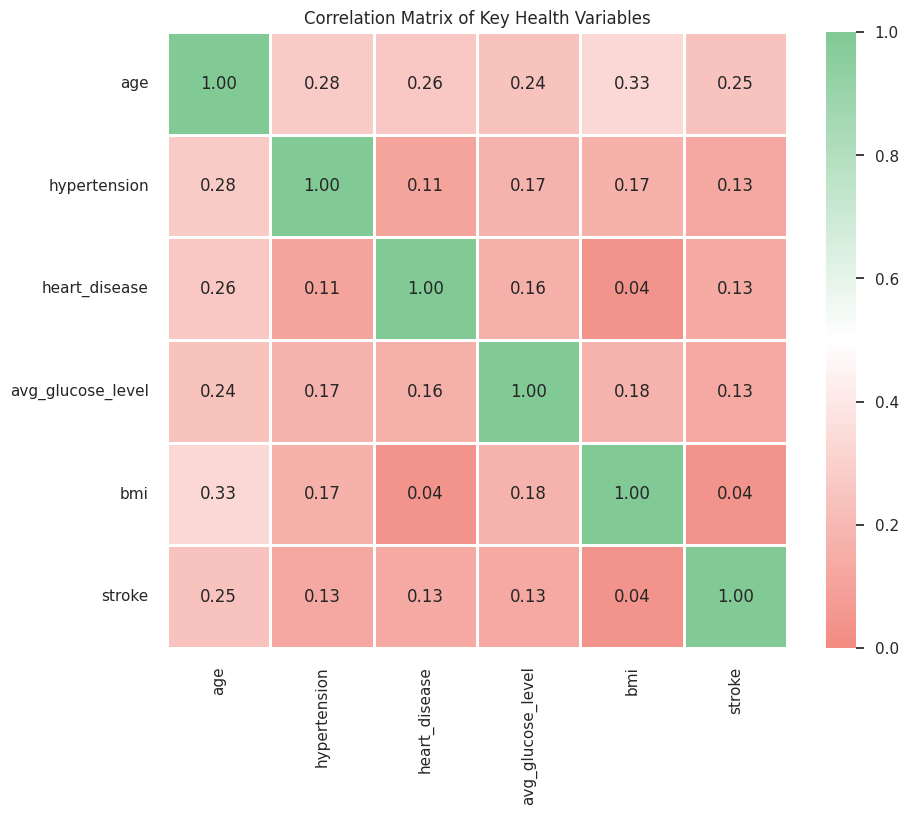

In [182]:
from matplotlib.colors import LinearSegmentedColormap

red_green_cmap = LinearSegmentedColormap.from_list(
    "red_green_light",
    ["#f28b82", "#ffffff", "#81c995"]
)

correlation_features = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
corr_matrix = sk[correlation_features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=red_green_cmap,
    linewidths=1.0,
    linecolor='white',
    vmin=0, vmax=1
)

plt.title('Correlation Matrix of Key Health Variables')
plt.show()

#**2. Data Preparation**

## Identifying Missing Values

In [183]:
# check for missing values in each column
sk.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [184]:
# check median BMI before imputation
bmi_median = sk['bmi'].median()
bmi_median

28.1

##Imputing Missing BMI Values

In [185]:
# impute missing BMI values with the median
sk['bmi'] = sk['bmi'].fillna(28.1)

In [186]:
# re-check missing values
sk.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


##Feature Engineering

In [187]:
sk[['hypertension', 'heart_disease']].head()

,hypertension,heart_disease
0,0,1
1,0,0
2,0,1
3,0,0
4,1,0


In [188]:
import numpy as np

conditions = [
    (sk['hypertension'] == 0) & (sk['heart_disease'] == 0),
    (sk['hypertension'] == 1) & (sk['heart_disease'] == 0),
    (sk['hypertension'] == 0) & (sk['heart_disease'] == 1),
    (sk['hypertension'] == 1) & (sk['heart_disease'] == 1)
]

choices = [
    'No HT, No HD',
    'HT, No HD',
    'No HT, HD',
    'HT and HD'
]

sk['ht_hd'] = np.select(conditions, choices, default='') # Added default=''

In [189]:
sk['ht_hd'].value_counts()

,count
ht_hd,
"No HT, No HD",4400
"HT, No HD",434
"No HT, HD",212
HT and HD,64


##Encoding Categorical Variables

In [190]:
# one-hot encode categorical variables
sk_encoded = pd.get_dummies(
    sk,
    columns=[
        'gender',
        'ever_married',
        'work_type',
        'Residence_type',
        'smoking_status'
    ],
    drop_first=True
)

In [191]:
sk_encoded.head()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,ht_hd,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,9046,67.0,0,1,228.69,36.6,1,"No HT, HD",True,False,True,False,True,False,False,True,True,False,False
1,51676,61.0,0,0,202.21,28.1,1,"No HT, No HD",False,False,True,False,False,True,False,False,False,True,False
2,31112,80.0,0,1,105.92,32.5,1,"No HT, HD",True,False,True,False,True,False,False,False,False,True,False
3,60182,49.0,0,0,171.23,34.4,1,"No HT, No HD",False,False,True,False,True,False,False,True,False,False,True
4,1665,79.0,1,0,174.12,24.0,1,"HT, No HD",False,False,True,False,False,True,False,False,False,True,False


In [192]:
sk_encoded.shape

(5110, 19)

##Scaling and Normalisation

In [193]:
from sklearn.preprocessing import StandardScaler

# create a scaler
scaler = StandardScaler()

# select numerical columns to scale
num_cols = ['age', 'avg_glucose_level', 'bmi']

# apply scaling
sk_encoded[num_cols] = scaler.fit_transform(sk_encoded[num_cols])

In [194]:
sk_encoded[num_cols].describe()

,age,avg_glucose_level,bmi
count,5.110000e+03,5.110000e+03,5.110000e+03
mean,5.005781e-17,1.001156e-16,-4.449583e-17
std,1.000098e+00,1.000098e+00,1.000098e+00
min,-1.908261e+00,-1.126958e+00,-2.411027e+00
25%,-8.061152e-01,-6.383223e-01,-6.575089e-01
50%,7.843218e-02,-3.149945e-01,-9.898092e-02
75%,7.860701e-01,1.754080e-01,5.115031e-01
max,1.714845e+00,3.657145e+00,8.928390e+00


##Outlier Removal (BMI and Average Glucose only)

In [195]:
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

bmi_bounds = iqr_bounds(sk['bmi'])
glucose_bounds = iqr_bounds(sk['avg_glucose_level'])

bmi_bounds, glucose_bounds

((np.float64(10.300000000000006), np.float64(46.29999999999999)),
 (np.float64(21.977500000000006), np.float64(169.35750000000002)))

In [196]:
sk_no_outliers = sk[
    (sk['bmi'].between(bmi_bounds[0], bmi_bounds[1])) &
    (sk['avg_glucose_level'].between(glucose_bounds[0], glucose_bounds[1]))
]

In [197]:
print("Original shape:", sk.shape)
print("After outlier removal:", sk_no_outliers.shape)

# Stroke class distribution before and after
print("\nStroke distribution (before):")
print(sk['stroke'].value_counts(normalize=True) * 100)

print("\nStroke distribution (after):")
print(sk_no_outliers['stroke'].value_counts(normalize=True) * 100)

Original shape: (5110, 13)
After outlier removal: (4391, 13)

Stroke distribution (before):
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

Stroke distribution (after):
stroke
0    96.242314
1     3.757686
Name: proportion, dtype: float64


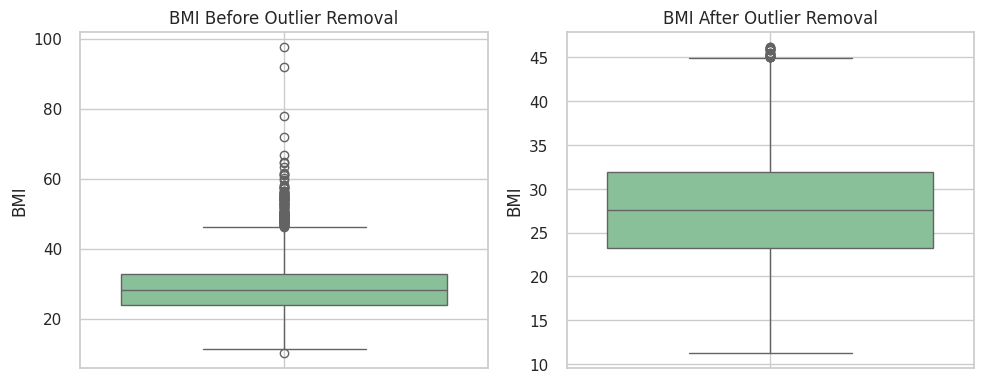

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))

# Before outlier removal
plt.subplot(1, 2, 1)
sns.boxplot(y=sk['bmi'], color='#81c995')
plt.title('BMI Before Outlier Removal')
plt.ylabel('BMI')
plt.grid(alpha=1.0)

# After outlier removal
plt.subplot(1, 2, 2)
sns.boxplot(y=sk_no_outliers['bmi'], color='#81c995')
plt.title('BMI After Outlier Removal')
plt.ylabel('BMI')
plt.grid(alpha=1.0)

plt.tight_layout()
plt.show()

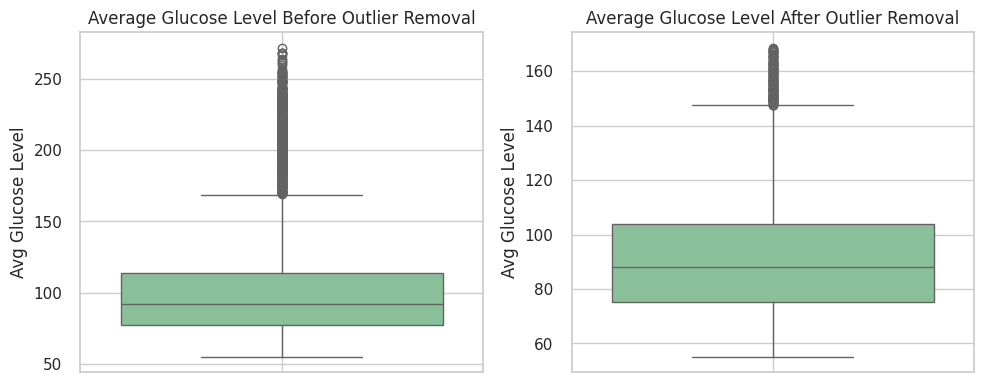

In [199]:
plt.figure(figsize=(10, 4))

# Before outlier removal
plt.subplot(1, 2, 1)
sns.boxplot(y=sk['avg_glucose_level'], color='#81c995')
plt.title('Average Glucose Level Before Outlier Removal')
plt.ylabel('Avg Glucose Level')
plt.grid(alpha=1.0)

# After outlier removal
plt.subplot(1, 2, 2)
sns.boxplot(y=sk_no_outliers['avg_glucose_level'], color='#81c995')
plt.title('Average Glucose Level After Outlier Removal')
plt.ylabel('Avg Glucose Level')
plt.grid(alpha=1.0)

plt.tight_layout()
plt.show()


##Post–Data Preparation Visualization

###Box Plot

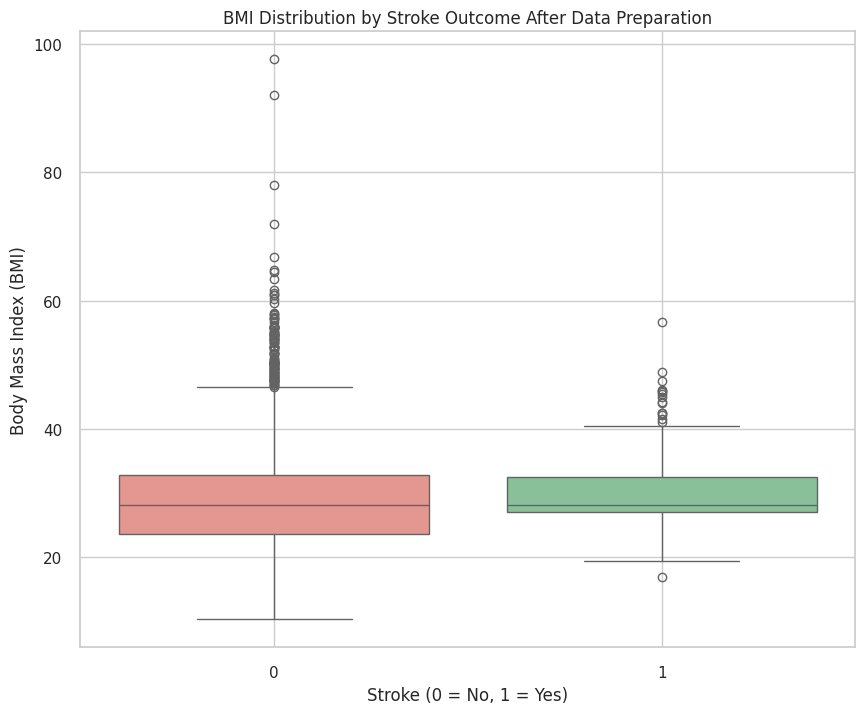

In [200]:
plt.figure(figsize=(10, 8))
sns.boxplot(
    x='stroke',
    y='bmi',
    data=sk,
    palette=palette
)

plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Body Mass Index (BMI)')
plt.title('BMI Distribution by Stroke Outcome After Data Preparation')

plt.grid(alpha=1.0)
plt.show()

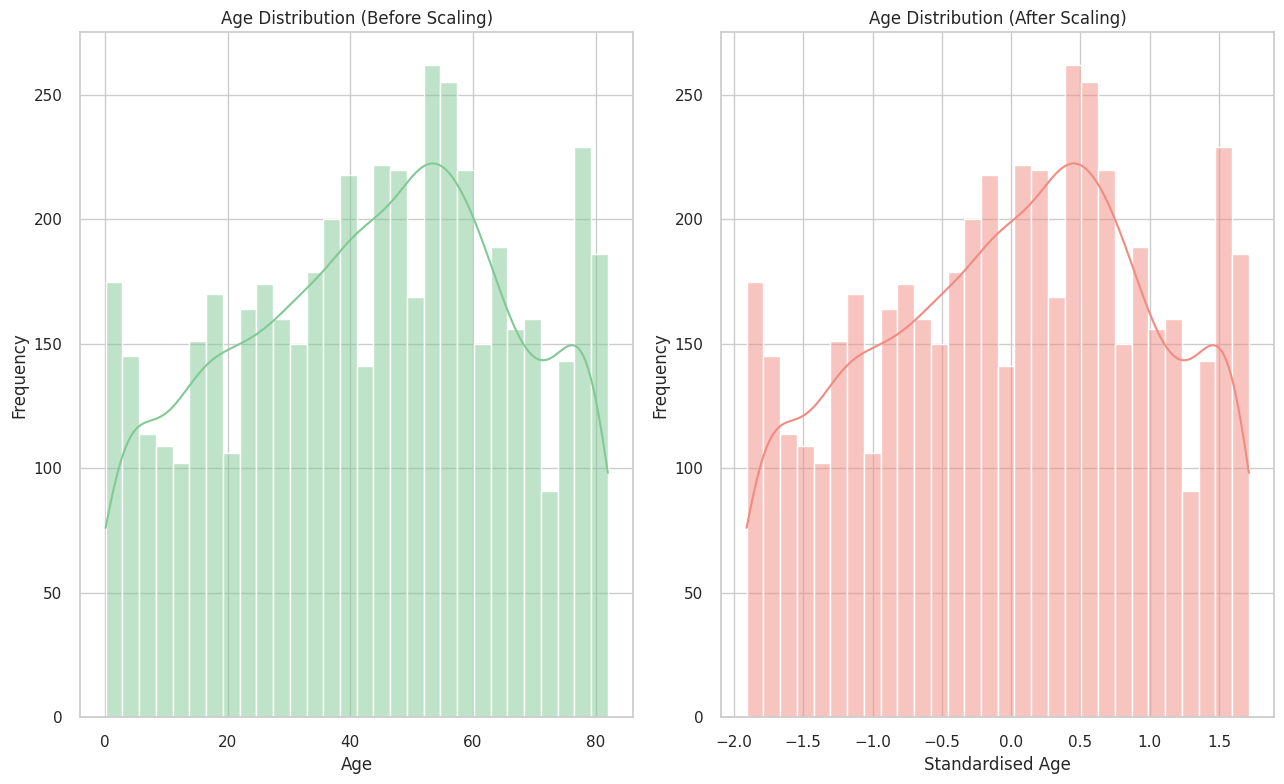

In [201]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(13, 8))

# Before scaling
plt.subplot(1, 2, 1)
sns.histplot(sk['age'], bins=30, kde=True, color='#81c995')
plt.title('Age Distribution (Before Scaling)')
plt.xlabel('Age')
plt.ylabel('Frequency')

# After scaling
plt.subplot(1, 2, 2)
sns.histplot(sk_encoded['age'], bins=30, kde=True, color='#f28b82')
plt.title('Age Distribution (After Scaling)')
plt.xlabel('Standardised Age')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

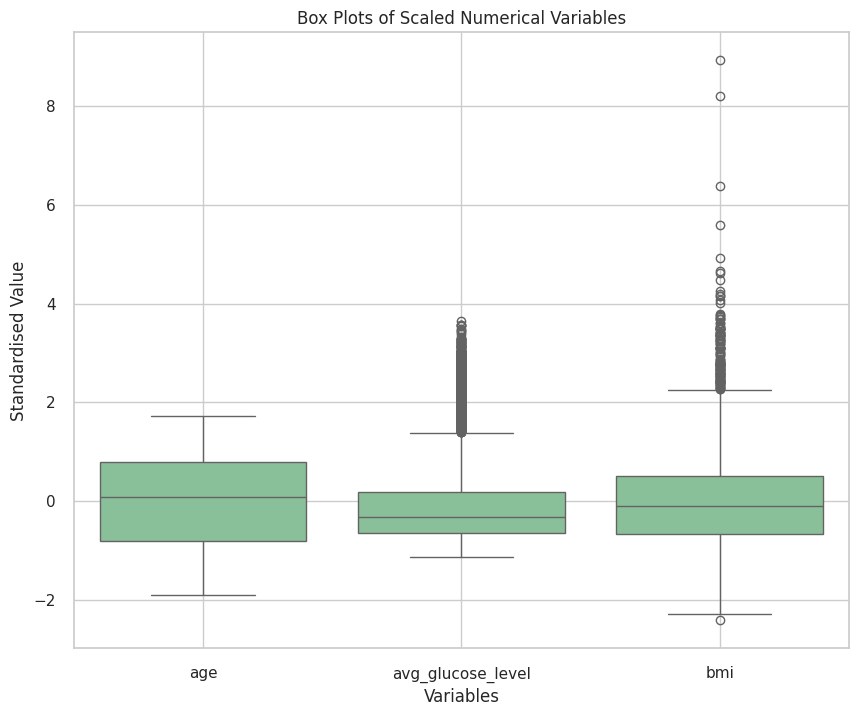

In [202]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.boxplot(
    data=sk_encoded[['age', 'avg_glucose_level', 'bmi']],
    palette=["#81c995"]
)

plt.title('Box Plots of Scaled Numerical Variables')
plt.ylabel('Standardised Value')
plt.xlabel('Variables')
plt.grid(alpha=1.0)

plt.show()

#**3. Classification**

##Train–Test Split (General Supervised Preparation)

In [203]:
from sklearn.model_selection import train_test_split

# features and target for classification
X = sk_encoded.drop('stroke', axis=1)
y = sk_encoded['stroke']

In [204]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [205]:
y_train.value_counts(normalize=True) * 100, y_test.value_counts(normalize=True) * 100

(stroke
 0    95.132094
 1     4.867906
 Name: proportion, dtype: float64,
 stroke
 0    95.107632
 1     4.892368
 Name: proportion, dtype: float64)

##Logistic Regression

In [206]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [207]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

In [208]:
#log_reg.fit(X_train, y_train)

In [209]:
X_train.dtypes

,0
id,int64
age,float64
hypertension,int64
heart_disease,int64
avg_glucose_level,float64
bmi,float64
ht_hd,object
gender_Male,bool
gender_Other,bool
ever_married_Yes,bool


In [210]:
sk_encoded = sk_encoded.drop(columns=['ht_hd'])

In [211]:
X = sk_encoded.drop('stroke', axis=1)
y = sk_encoded['stroke']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Smote training

In [256]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("original X train shape:", X_train.shape)
print("x_train shape after.SMOTE:",X_train_smote.shape)
print("Original y_train shape:", y_train.shape)
print("y_train shape after SMOTE:", y_train_smote.shape)


original X train shape: (4088, 17)
x_train shape after.SMOTE: (7778, 17)
Original y_train shape: (4088,)
y_train shape after SMOTE: (7778,)


In [213]:
X = sk_encoded.drop('stroke', axis=1)
y = sk_encoded['stroke']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [214]:
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [257]:
# Select numerical features for clustering
numerical_features = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the selected features
scaled_features = scaler.fit_transform(sk[numerical_features])

# Create a DataFrame for scaled features (optional, but good practice for readability)
scaled_features_df = pd.DataFrame(scaled_features, columns=numerical_features)

# Assign to scaled_features_iris for compatibility with existing commented code
scaled_features_iris = scaled_features_df.copy()

In [216]:
ylrpred = log_reg.predict(X_test)
cm = confusion_matrix(y_test, ylrpred)
print(cm)

[[723 249]
 [ 10  40]]


<Axes: >

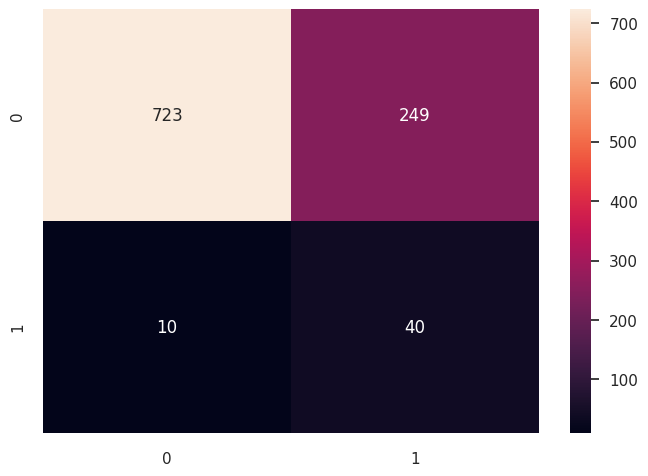

In [217]:
sns.heatmap(cm, annot=True, fmt='d')

In [218]:
print(classification_report(y_test, ylrpred))
print("Accuracy:", accuracy_score(y_test, ylrpred))
print("Precision:", precision_score(y_test, ylrpred))
print("Recall:", recall_score(y_test, ylrpred))
print("F1 Score:", f1_score(y_test, ylrpred))
#print(classification_report(y_test, ylrpred, zero_division=0))


              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022

Accuracy: 0.7465753424657534
Precision: 0.1384083044982699
Recall: 0.8
F1 Score: 0.2359882005899705


##SVC

In [219]:
svm =SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [220]:
ysvm_pred = svm.predict(X_test)
cm = confusion_matrix(y_test, ysvm_pred)
print(cm)

[[971   1]
 [ 49   1]]


<Axes: >

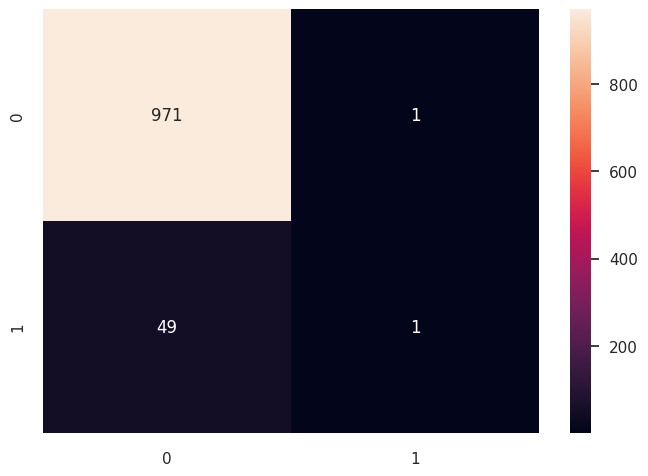

In [221]:
sns.heatmap(cm, annot=True, fmt='d')

In [222]:
print(classification_report(y_test, ysvm_pred))
print("Accuracy:", accuracy_score(y_test, ysvm_pred))
print("F1_score:", f1_score(y_test, ysvm_pred, average='weighted'))
F1_svm=f1_score(y_test, ysvm_pred, average='weighted')
print("Precision:", precision_score(y_test, ysvm_pred))
print("Recall:", recall_score(y_test, ysvm_pred))
#print("Precision:", precision_score(y_test, ysvm_pred))
#print("Recall:", recall_score(y_test, ysvm_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.50      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.73      0.51      0.51      1022
weighted avg       0.93      0.95      0.93      1022

Accuracy: 0.9510763209393346
F1_score: 0.9290856032892673
Precision: 0.5
Recall: 0.02


##Decision Tree Classifier

In [223]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [224]:
ytree_pred = tree.predict(X_test)
cm = confusion_matrix(y_test, ytree_pred)
print(cm)

[[929  43]
 [ 45   5]]


<Axes: >

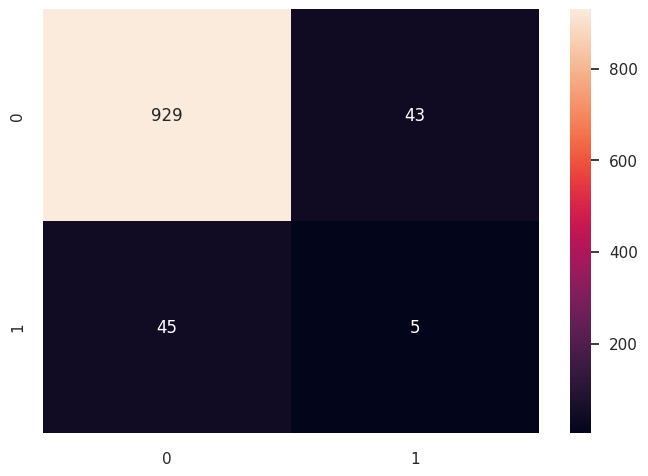

In [225]:

sns.heatmap(cm, annot=True, fmt='d')

In [226]:
print(classification_report(y_test, ytree_pred))
print("Accuracy:", accuracy_score(y_test, ytree_pred))
print("F1_score:", f1_score(y_test, ytree_pred, average='weighted'))
F1_tree=f1_score(y_test, ytree_pred, average='weighted')

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       972
           1       0.10      0.10      0.10        50

    accuracy                           0.91      1022
   macro avg       0.53      0.53      0.53      1022
weighted avg       0.91      0.91      0.91      1022

Accuracy: 0.913894324853229
F1_score: 0.9130599430356271


## KNeighbors Classifier

In [227]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [228]:
yknn_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, yknn_pred)
print(cm)

[[972   0]
 [ 50   0]]


<Axes: >

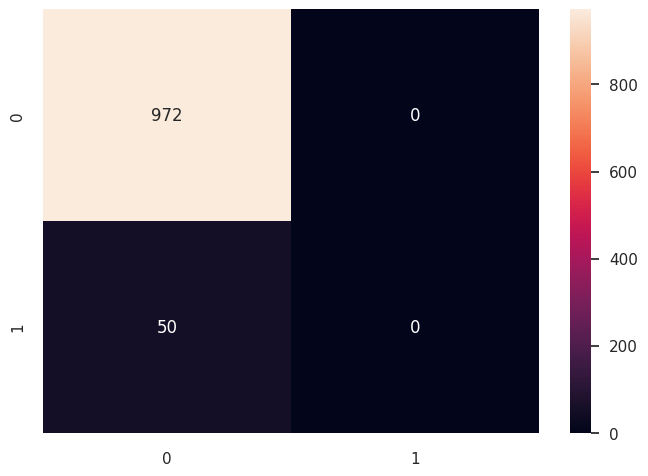

In [229]:
sns.heatmap(cm, annot=True, fmt='d')

In [230]:
print(classification_report(y_test, yknn_pred))
print("Accuracy:", accuracy_score(y_test, yknn_pred))
print("F1_score:", f1_score(y_test, yknn_pred, average='weighted'))
F1_knn=f1_score(y_test, yknn_pred, average='weighted')

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

Accuracy: 0.9510763209393346
F1_score: 0.9272278675557003


##Random Forest Classifier

In [231]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [232]:
yrf_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, yrf_pred)
print(cm)

[[970   2]
 [ 49   1]]


<Axes: >

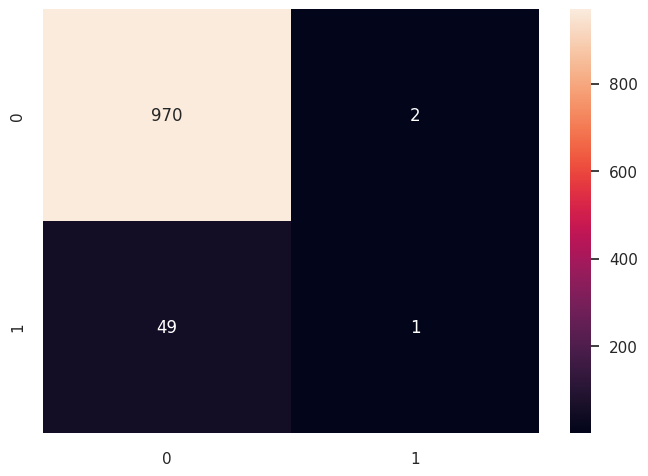

In [233]:
sns.heatmap(cm, annot=True, fmt='d')

#**4. Regression**

#**5. Clustering**

In [234]:
!pip install yellowbrick

In [235]:
!pip install matplotlib-venn

### KMeans Clustering

In [236]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_features_iris)

KMeans(n_clusters=3, random_state=42)

In [237]:
kmeans.cluster_centers_

array([[-0.92650359, -0.32447218, -0.67493241, -0.32860186, -0.23466207],
       [ 0.58670831,  0.15925321,  0.45301937, -0.32860186,  0.12580999],
       [ 0.84113226,  0.53095807,  0.48171705,  3.04319637,  0.32959666]])

In [238]:
from sklearn.metrics import silhouette_score
kmeans_silhouette = silhouette_score(scaled_features_iris, kmeans.labels_).round(2)
kmeans_silhouette

np.float64(0.28)

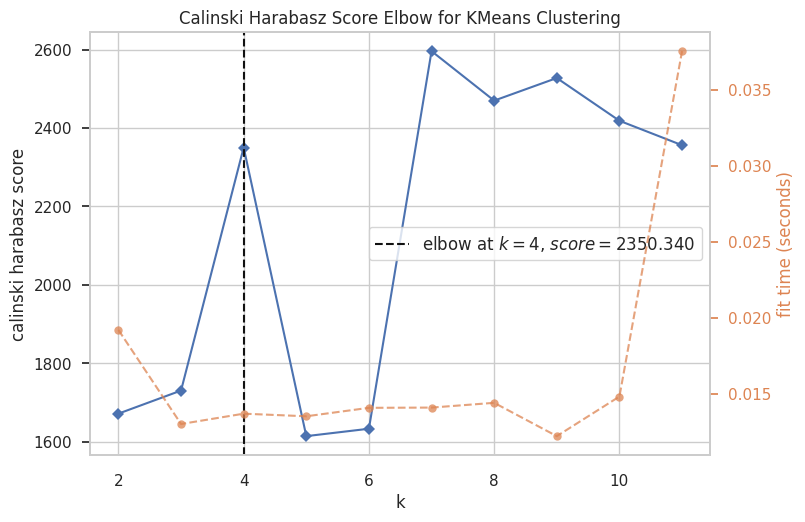

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [239]:
from sklearn import metrics
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2,12), metric='calinski_harabasz')
visualizer.fit(scaled_features_iris)
visualizer.show()

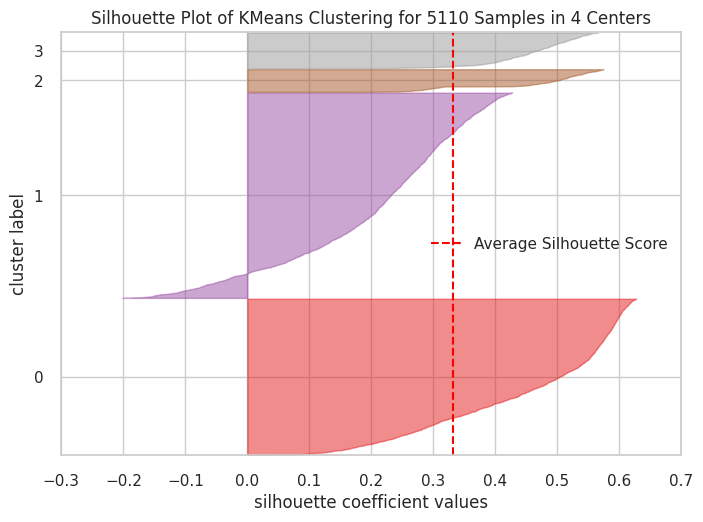

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 5110 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [240]:
model = KMeans(n_clusters=4, random_state=42)
visualizer = SilhouetteVisualizer(model)

visualizer.fit(scaled_features_iris)
visualizer.show()

In [241]:
scaled_features_iris.shape

(5110, 5)

Text(0.5, 1.0, 'K_Means')

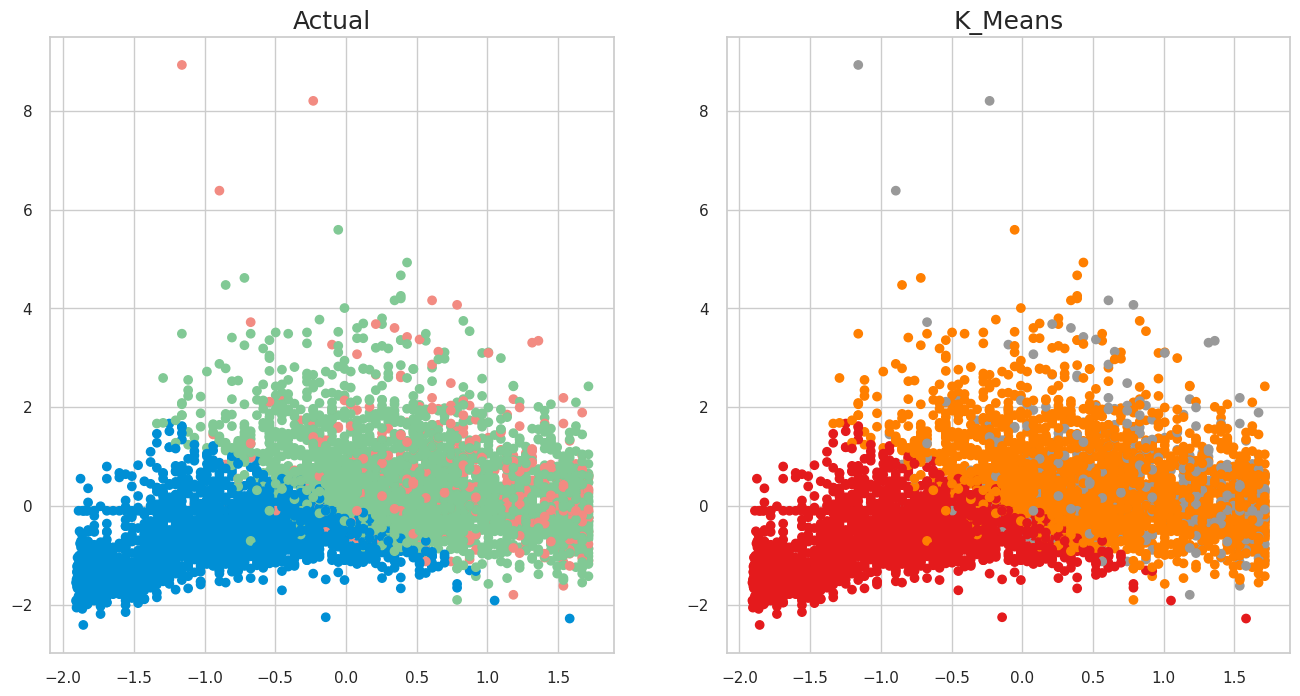

In [242]:
fig, axes = plt.subplots(1, 2, figsize=(16,8))

fte_colors = {0: "#008fd5", 1: "#81c995", 2: "#f28b82"} # Added a color for label 2

km_colors = [fte_colors[label] for label in kmeans.labels_]

axes[0].scatter(scaled_features_iris['age'], scaled_features_iris['bmi'], c=km_colors) # Changed column names
axes[1].scatter(scaled_features_iris['age'], scaled_features_iris['bmi'], c=kmeans.labels_, cmap=plt.cm.Set1) # Changed column names
axes[0].set_title('Actual', fontsize=18)
axes[1].set_title('K_Means', fontsize=18)

In [243]:
kmeans.labels_

array([1, 1, 1, ..., 0, 1, 0], dtype=int32)

In [244]:
scaled_features_iris['cluster'] = kmeans.labels_

In [245]:
cluster1=scaled_features_iris[scaled_features_iris['cluster']==0]
cluster2=scaled_features_iris[scaled_features_iris['cluster']==1]
cluster3=scaled_features_iris[scaled_features_iris['cluster']==2]

In [246]:
kmeans.labels_ == 0

array([False, False, False, ...,  True, False,  True])

In [247]:
cluster1.head()

,age,avg_glucose_level,bmi,hypertension,heart_disease,cluster
31,-0.054250,-0.502167,-0.449685,-0.328602,-0.238947,0
118,-0.231159,-0.527123,-0.631531,-0.328602,-0.238947,0
133,-0.231159,-0.103749,-0.098981,-0.328602,-0.238947,0
162,-1.853419,-0.790158,-0.098981,-0.328602,-0.238947,0
182,-0.496524,-0.662947,0.134821,-0.328602,-0.238947,0


In [248]:
cluster1.shape

(2055, 6)

In [249]:
cluster1.describe()

,age,avg_glucose_level,bmi,hypertension,heart_disease,cluster
count,2055.000000,2055.000000,2055.000000,2.055000e+03,2055.000000,2055.0
mean,-0.931631,-0.323804,-0.676838,-3.286019e-01,-0.234641,0.0
std,0.625506,0.557944,0.640260,6.329812e-15,0.137980,0.0
min,-1.908261,-1.126958,-2.411027,-3.286019e-01,-0.238947,0.0
25%,-1.425298,-0.710872,-1.138103,-3.286019e-01,-0.238947,0.0
50%,-0.983025,-0.423764,-0.709465,-3.286019e-01,-0.238947,0.0
75%,-0.496524,-0.057260,-0.235366,-3.286019e-01,-0.238947,0.0
max,1.582163,3.018881,1.667526,-3.286019e-01,4.185032,0.0


### DBSCAN Clustering

In [250]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(scaled_features_iris)

DBSCAN()

In [251]:
dbscan_labels = dbscan.labels_
print(dbscan_labels)

[5 0 1 ... 6 0 6]


In [252]:
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

if n_clusters_dbscan > 1:
  dbscan_silhouette = silhouette_score(scaled_features_iris, dbscan_labels).round(2)
  print(f"DBSCAN Silhouette score: {dbscan_silhouette}")
else:
  print("cannot compute silhouette score: Less than 2 clusters formed (or only noise points).")
  #dbscan_silhouette = 0
#n_noise_dbscan = list(dbscan_labels).count(-1)

DBSCAN Silhouette score: 0.37


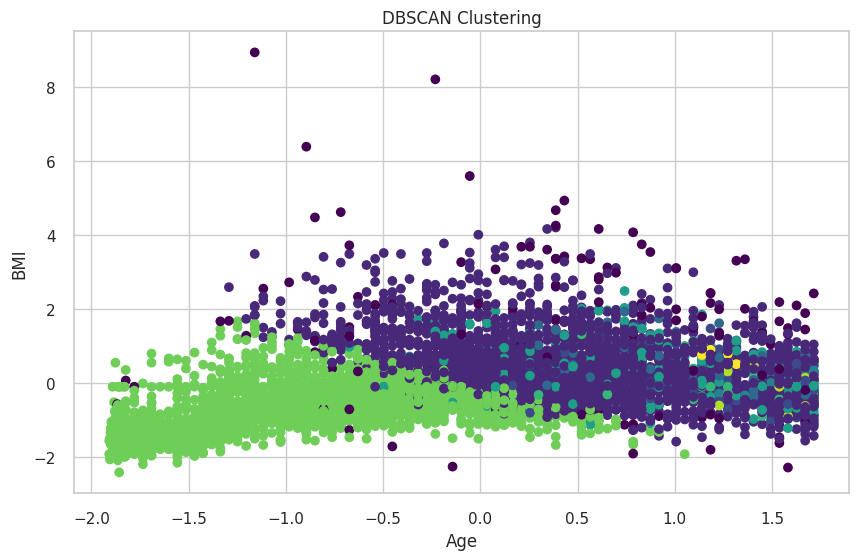

In [253]:
plt.figure(figsize=(10, 6))
plt.scatter(scaled_features_iris['age'], scaled_features_iris['bmi'], c=dbscan_labels, cmap='viridis')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('DBSCAN Clustering')
plt.show()

In [254]:
scaled_features_iris['dbscan_cluster'] = dbscan_labels
display(scaled_features_iris.head())

,age,avg_glucose_level,bmi,hypertension,heart_disease,cluster,dbscan_cluster
0,1.051434,2.706375,1.005086,-0.328602,4.185032,1,5
1,0.786070,2.121559,-0.098981,-0.328602,-0.238947,1,0
2,1.626390,-0.005028,0.472536,-0.328602,4.185032,1,1
3,0.255342,1.437358,0.719327,-0.328602,-0.238947,1,0
4,1.582163,1.501184,-0.631531,3.043196,-0.238947,2,2


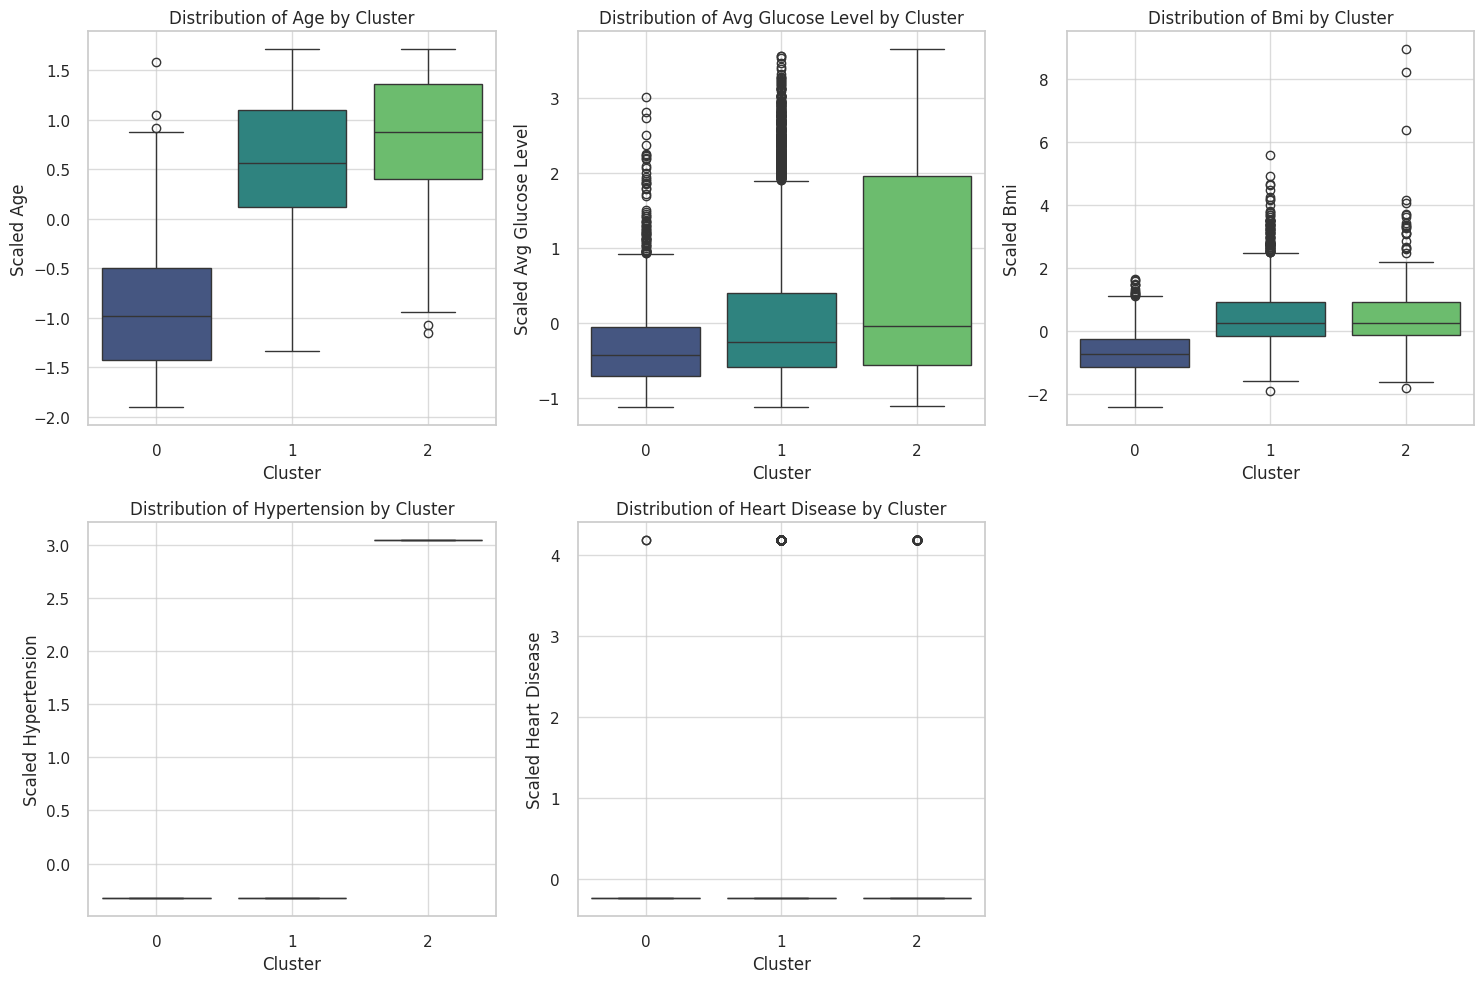

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of numerical features that were used for clustering
numerical_features_in_clusters = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']

# Set up the plotting area
plt.figure(figsize=(15, 10))

# Loop through each numerical feature and create a box plot grouped by cluster
for i, feature in enumerate(numerical_features_in_clusters):
    plt.subplot(2, 3, i + 1) # Create a 2x3 grid of subplots
    sns.boxplot(x='cluster', y=feature, data=scaled_features_iris, palette='viridis')
    plt.title(f'Distribution of {feature.replace("_", " ").title()} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(f'Scaled {feature.replace("_", " ").title()}')
    plt.grid(alpha=0.7)

plt.tight_layout()
plt.show()